In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('AusApparalSales4thQrt2020.csv')
df


,Date,Time,State,Group,Unit,Sales
0,1-Oct-20,Morning,WA,Kids,8,20000
1,1-Oct-20,Morning,WA,Men,8,20000
2,1-Oct-20,Morning,WA,Women,4,10000
3,1-Oct-20,Morning,WA,Seniors,15,37500
4,1-Oct-20,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-20,Evening,TAS,Kids,15,37500
7557,30-Dec-20,Evening,TAS,Men,15,37500
7558,30-Dec-20,Evening,TAS,Women,11,27500


# State Generating highest revenue

In [9]:
state_rev=df.groupby(['State'])['Sales'].sum().reset_index(name='Revenue')
state_rev

,State,Revenue
0,NSW,74970000
1,NT,22580000
2,QLD,33417500
3,SA,58857500
4,TAS,22760000
5,VIC,105565000
6,WA,22152500


In [10]:
# Method 1: Using groupby

In [11]:
df.groupby('State')['Sales'].sum().max()


105565000

In [12]:
# Method2: Using Revenue column

In [13]:
state_rev['Revenue'].max()



105565000

In [14]:
# Method3: Name of the State with revenue

In [15]:
state_rev.loc[state_rev['Revenue'].idxmax()]

State            VIC
Revenue    105565000
Name: 5, dtype: object

In [ ]:
# State generating minimum revenue

In [16]:
state_rev.loc[state_rev['Revenue'].idxmin()]

State            WA
Revenue    22152500
Name: 6, dtype: object

## Data Wrangling

In [ ]:
# identify the data for missing values

In [8]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [ ]:
# identify numeric columns

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)


Index(['Unit', 'Sales'], dtype='object')


In [ ]:
# Data Normalization-Normalizing sales column

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = df.copy()

df_normalized[num_cols] = scaler.fit_transform(df[num_cols])
df_normalized


,Date,Time,State,Group,Unit,Sales
0,1-Oct-20,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-20,Morning,WA,Men,0.095238,0.095238
2,1-Oct-20,Morning,WA,Women,0.031746,0.031746
3,1-Oct-20,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-20,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TAS,Seniors,0.190476,0.190476
7556,30-Dec-20,Evening,TAS,Kids,0.206349,0.206349
7557,30-Dec-20,Evening,TAS,Men,0.206349,0.206349
7558,30-Dec-20,Evening,TAS,Women,0.142857,0.142857


In [11]:
df['Sales_normalized'] = (
    (df['Sales'] - df['Sales'].min()) /
    (df['Sales'].max() - df['Sales'].min())
)


In [12]:
df

,Date,Time,State,Group,Unit,Sales,Sales_normalized
0,1-Oct-20,Morning,WA,Kids,8,20000,0.095238
1,1-Oct-20,Morning,WA,Men,8,20000,0.095238
2,1-Oct-20,Morning,WA,Women,4,10000,0.031746
3,1-Oct-20,Morning,WA,Seniors,15,37500,0.206349
4,1-Oct-20,Afternoon,WA,Kids,3,7500,0.015873
...,...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TAS,Seniors,14,35000,0.190476
7556,30-Dec-20,Evening,TAS,Kids,15,37500,0.206349
7557,30-Dec-20,Evening,TAS,Men,15,37500,0.206349
7558,30-Dec-20,Evening,TAS,Women,11,27500,0.142857


## Groupby for Data Chunking- Data chunking means splitting a dataset into logical groups based on one or more keys so that you can analyze each group separately.

In [13]:
df.groupby('State')['Sales'].sum().reset_index(name='Revenue')

,State,Revenue
0,NSW,74970000
1,NT,22580000
2,QLD,33417500
3,SA,58857500
4,TAS,22760000
5,VIC,105565000
6,WA,22152500


In [14]:
df['Sales']

0       20000
1       20000
2       10000
3       37500
4        7500
        ...  
7555    35000
7556    37500
7557    37500
7558    27500
7559    32500
Name: Sales, Length: 7560, dtype: int64

## Groupby for Data Merging-Here, groupby() is used to summarize data first, and then the result is merged back into the original dataset or another table.

In [15]:
avg_sale = (
    df.groupby('Time')['Sales'].mean()
      .reset_index(name='Avg_Sales')
)

df = df.merge(avg_sale, on='Time', how='left')
df

,Date,Time,State,Group,Unit,Sales,Sales_normalized,Avg_Sales
0,1-Oct-20,Morning,WA,Kids,8,20000,0.095238,45320.436508
1,1-Oct-20,Morning,WA,Men,8,20000,0.095238,45320.436508
2,1-Oct-20,Morning,WA,Women,4,10000,0.031746,45320.436508
3,1-Oct-20,Morning,WA,Seniors,15,37500,0.206349,45320.436508
4,1-Oct-20,Afternoon,WA,Kids,3,7500,0.015873,45241.071429
...,...,...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TAS,Seniors,14,35000,0.190476,45241.071429
7556,30-Dec-20,Evening,TAS,Kids,15,37500,0.206349,44479.166667
7557,30-Dec-20,Evening,TAS,Men,15,37500,0.206349,44479.166667
7558,30-Dec-20,Evening,TAS,Women,11,27500,0.142857,44479.166667


In [16]:
df.groupby('State', as_index=False).agg(
    Revenue=('Sales', 'sum')
)


,State,Revenue
0,NSW,74970000
1,NT,22580000
2,QLD,33417500
3,SA,58857500
4,TAS,22760000
5,VIC,105565000
6,WA,22152500


In [21]:
#df_aggregated =  df.groupby(['Unit', 'Sales']).agg({'Sales': ['mean', 'median', 'std', 'var', 'count', 'sum']})
#df_aggregated

## Descriptive Statistics

In [20]:
df[['Sales', 'Unit']].describe()


,Sales,Unit
count,7560.000000,7560.000000
mean,45013.558201,18.005423
std,32253.506944,12.901403
min,5000.000000,2.000000
25%,20000.000000,8.000000
50%,35000.000000,14.000000
75%,65000.000000,26.000000
max,162500.000000,65.000000


# State with highest sale

In [23]:
state_rev.loc[state_rev['Revenue'].idxmax()]


State            VIC
Revenue    105565000
Name: 5, dtype: object

In [25]:
## Sate with lowest sale

In [24]:
state_rev.loc[state_rev['Revenue'].idxmin()]

State            WA
Revenue    22152500
Name: 6, dtype: object

In [26]:
import pandas as pd
import matplotlib.pyplot as plt


In [30]:


# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)


# Weekly Data

In [31]:
weekly_sales = df['Sales'].resample('W').sum()
print(weekly_sales.head())


Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
Freq: W-SUN, Name: Sales, dtype: int64


# Descriptive statistics(Weekly)

In [32]:
weekly_stats = weekly_sales.describe()
print(weekly_stats)


count    1.400000e+01
mean     2.430732e+07
std      5.893363e+06
min      1.379250e+07
25%      2.112750e+07
50%      2.422375e+07
75%      2.896750e+07
max      3.177000e+07
Name: Sales, dtype: float64


# weekly sales Trend(Line Chart)

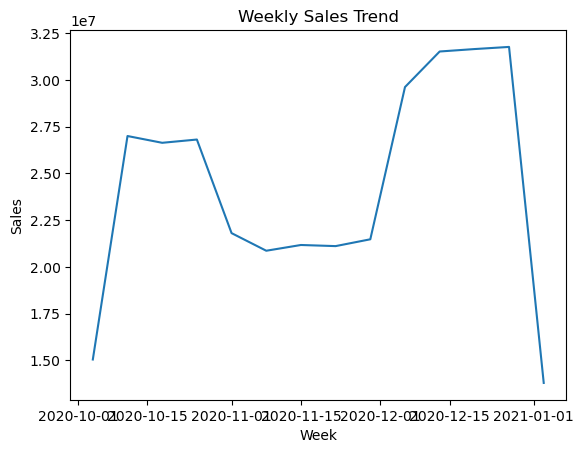

In [33]:
plt.figure()
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.show()


# Outlier Detection using IQR

In [34]:
Q1 = weekly_sales.quantile(0.25)
Q3 = weekly_sales.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = weekly_sales[(weekly_sales < lower_bound) | 
                         (weekly_sales > upper_bound)]

print("Weekly Sales Outliers:")
print(outliers)


Weekly Sales Outliers:
Series([], Freq: W-SUN, Name: Sales, dtype: int64)


Analysis: weekly sales do not contain extreme values.

This is very common when:

Data is smooth

Variability is low

Aggregation (weekly) reduces extremes

# BoxPlot

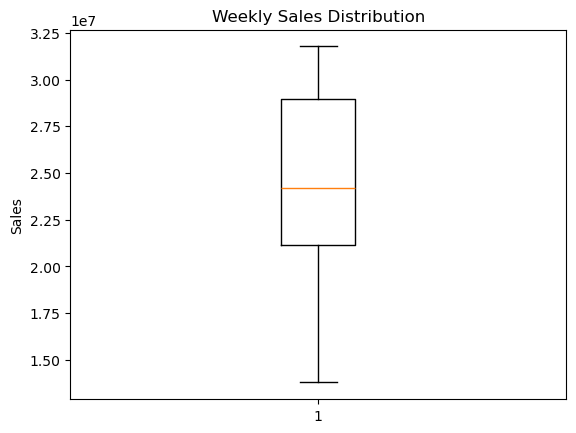

In [35]:
plt.figure()
plt.boxplot(weekly_sales)
plt.title("Weekly Sales Distribution")
plt.ylabel("Sales")
plt.show()


# Monthly Data

In [38]:
monthly_sales = df['Sales'].resample('ME').sum()
print(monthly_sales.head())


Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64


# Descriptive statistics(Monthly)

In [39]:
monthly_stats = monthly_sales.describe()
print(monthly_stats)


count    3.000000e+00
mean     1.134342e+08
std      2.233605e+07
min      9.068250e+07
25%      1.024862e+08
50%      1.142900e+08
75%      1.248100e+08
max      1.353300e+08
Name: Sales, dtype: float64


# Monthly sales Trend(Line Chart)

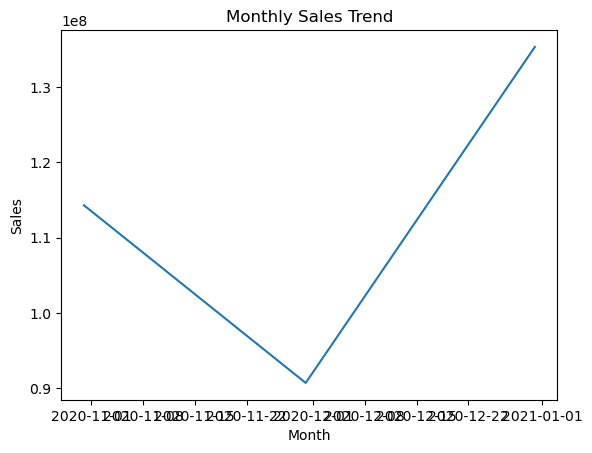

In [40]:
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


In [45]:
from scipy import stats

In [49]:
mean_sales = monthly_sales.mean()
median_sales = monthly_sales.median()
std_sales = monthly_sales.std()
mode_sales = stats.mode(monthly_sales, keepdims=True)
skewness = stats.skew(monthly_sales)
kurtosis = stats.kurtosis(monthly_sales)



In [50]:
print("Monthly Sales Statistics")
print("-------------------------")
print("Mean:", mean_sales)
print("Median:", median_sales)
print("Mode:", mode_sales.mode[0])
print("Standard Deviation:", std_sales)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


Monthly Sales Statistics
-------------------------
Mean: 113434166.66666667
Median: 114290000.0
Mode: 90682500
Standard Deviation: 22336050.503241017
Skewness: -0.07028807224763836
Kurtosis: -1.4999999999999996


# Z- Score Method of finding outliers

In [51]:
z_scores = stats.zscore(monthly_sales)

outliers = monthly_sales[abs(z_scores) > 3]

print("Monthly Sales Outliers (Z-score method):")
print(outliers)


Monthly Sales Outliers (Z-score method):
Series([], Freq: ME, Name: Sales, dtype: int64)


In [ ]:
# Monthly Sales Trend(Line chart)

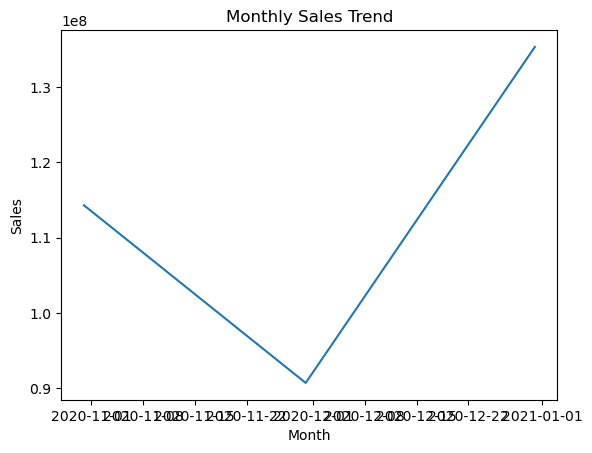

In [52]:
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


# Monthly Sales Distribution (Histogram)

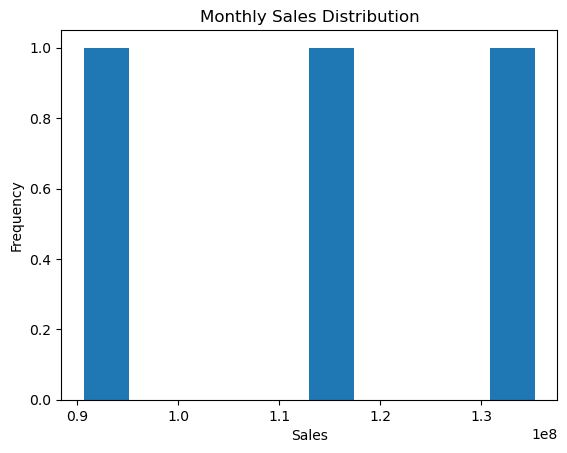

In [53]:
plt.figure()
plt.hist(monthly_sales)
plt.title("Monthly Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Quaterly Data- 
Since data is available for only one quarter, the quarterly analysis focuses on internal performance trends, variability,
and distribution of Sales and Units rather than quarter-over-quarter comparisons.

In [44]:
quaterly_sales = df['Sales'].resample('QE').sum()
print(quaterly_sales.head())


Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


In [54]:
monthly_sales = df['Sales'].resample('ME').sum()
print(monthly_sales.head())


Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64


# Pie Chart-This code aggregates monthly sales and uses a pie chart to show each month’s percentage contribution to total quarterly sales.

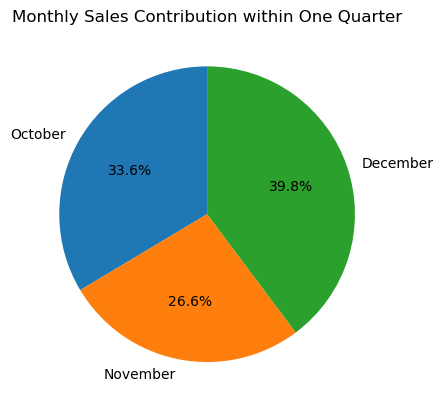

In [55]:
plt.figure()
plt.pie(
    monthly_sales,
    labels=monthly_sales.index.strftime('%B'),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Monthly Sales Contribution within One Quarter")
plt.show()



# Descriptive statistics for the Quarter

In [59]:
quarter_mean = df['Sales'].mean()
quarter_median = df['Sales'].median()
quarter_std = df['Sales'].std()

print("Mean=:",quarter_mean,
      "Median=:", quarter_median,
      "Standard Deviation=:", quarter_std)


Mean=: 45013.5582010582 Median=: 35000.0 Standard Deviation=: 32253.506943966317


#  Distribution & variability analysis

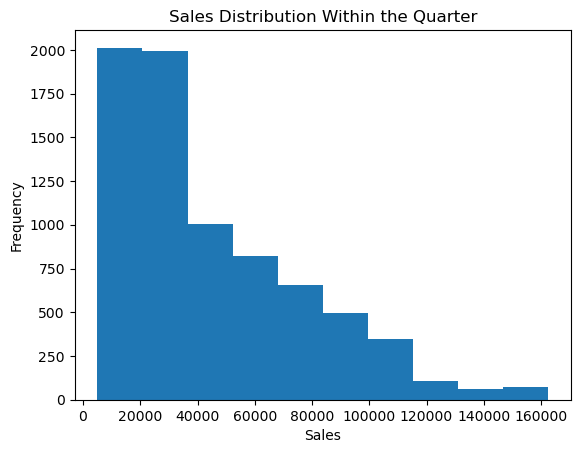

In [60]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Sales'])
plt.title("Sales Distribution Within the Quarter")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


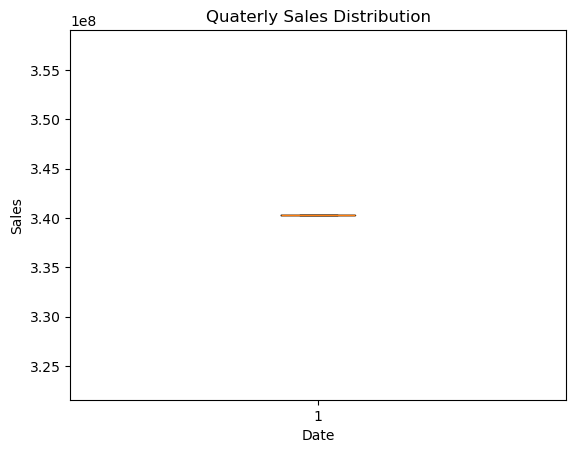

In [63]:
plt.figure()
plt.boxplot(quaterly_sales)
plt.title("Quaterly Sales Distribution")
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()


# The quarterly boxplot appears as a single line because only one quarter of data is available,resulting in no measurable variability at the quarterly level.

# Outlier Analysis within the Quarter

In [64]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

outliers = df['Sales'][
    (df['Sales'] < Q1 - 1.5*IQR) |
    (df['Sales'] > Q3 + 1.5*IQR)
]

print(outliers)


Date
2020-12-01    157500
2020-12-01    155000
2020-12-02    140000
2020-12-02    147500
2020-12-02    160000
               ...  
2020-12-29    162500
2020-12-29    135000
2020-12-29    135000
2020-12-30    162500
2020-12-30    155000
Name: Sales, Length: 123, dtype: int64


# Trend Analysis inside the Quarter

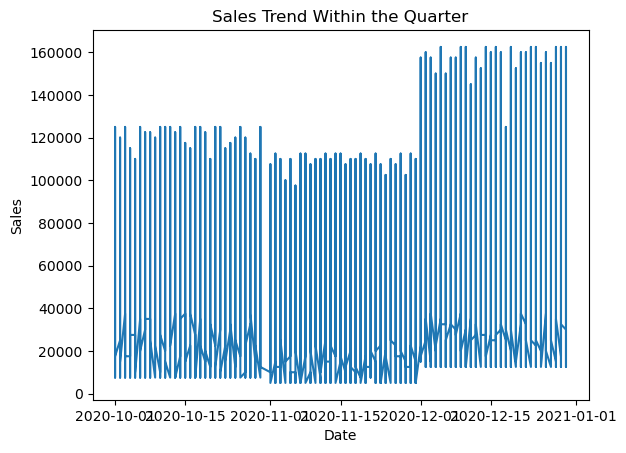

In [65]:
plt.figure()
plt.plot(df.index, df['Sales'])
plt.title("Sales Trend Within the Quarter")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


# Sales and Units Performance Analysis Report

Reporting Period: Weekly, Monthly, and Quarterly
Dataset: Sales Revenue and Units Sold
Analysis Type: Descriptive Statistical Analysis

1. Weekly Sales and Units Analysis
This section analyzes short-term performance of Sales and Units sold. Weekly aggregation helps monitor operational consistency and detect unusual patterns.
- Mean and median values indicate average weekly performance.
- Standard deviation highlights variability in weekly sales and units.
- Line charts were used to visualize weekly trends.
- IQR-based outlier detection was applied to identify abnormal weeks.
2. Monthly Sales and Units Analysis
Monthly analysis focuses on identifying patterns and variability across months within the quarter. Aggregation at this level reduces daily noise and provides clearer insights.
- Descriptive statistics such as mean, median, mode, and standard deviation were calculated.
- SciPy was used to compute skewness, kurtosis, and Z-score based outliers.
- Boxplots and histograms were used to study distribution and spread.
3. Quarterly Sales and Units Analysis
Since data is available for only one quarter, the quarterly analysis focuses on overall aggregation and internal trends rather than quarter-over-quarter comparison.
- Total quarterly sales and units were calculated.
- Monthly contribution to quarterly sales was visualized using a pie chart.
- Trend analysis was performed using weekly and monthly breakdowns.
4. Conclusion
Descriptive statistical analysis of Sales and Units data provides valuable insights into short-term trends, monthly variability, and overall quarterly performance. The combination of numerical summaries and visualizations supports effective decision-making.

   
   
   
 